# Small-footprint keyword spotting
## 3. Recurrent neural networks for speech command recognition

This notebook extends the CNN experiments by evaluating recurrent neural networks for speech command recognition.
Four configurations are trained: LSTM and BiLSTM models using either STFT or MFCC features.

 All experiments use the same dataset partitions as the CNN models. The objective is to investigate whether recurrent architectures can capture temporal patterns in speech more effectively than the CNN baseline.
 
Each model is trained from scratch using early stopping and model checkpoints. Performance is evaluated using test accuracy, per-class classification metrics, and confusion matrices.

In [1]:
from pathlib import Path
import sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from preprocessing import load_audio, extract_stft, extract_mfcc

DATA_DIR = PROJECT_ROOT / "data/raw/speech_commands_v0.02"
MANIFEST_PATH = PROJECT_ROOT / "data/processed/speech_commands_manifest.csv"
LABELS_PATH = PROJECT_ROOT / "data/processed/labels.json"
OUT = PROJECT_ROOT / "results/rnn"
MODEL_DIR = PROJECT_ROOT / "models"
OUT.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(MANIFEST_PATH)
labels = json.loads(LABELS_PATH.read_text())
num_classes = len(labels)
assert set(manifest["split"].unique()) == {"train", "validation", "test"}
assert manifest["label_id"].between(0, num_classes - 1).all()
print(manifest.groupby("split").size())
print("Classes:", num_classes, "GPUs:", tf.config.list_physical_devices("GPU"))

2026-10-08 18:21:20.598527: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791476480.686911    5750 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791476480.712128    5750 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791476480.897963    5750 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791476480.898003    5750 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791476480.898004    5750 computation_placer.cc:177] computation placer alr

split
test          11005
train         84843
validation     9981
dtype: int64
Classes: 35 GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Build sequence datasets

Unlike the CNN models, the recurrent networks process acoustic features as sequences.
STFT produces sequences of shape (124, 129), while MFCC produces (99, 13). The same preprocessing functions used in the previous notebooks are retained to ensure consistent feature extraction during training and inference.

Features are extracted during data loading rather than storing the entire dataset in memory.

In [2]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 40
PATIENCE = 10
FEATURE_SHAPES = {"STFT": (124, 129), "MFCC": (99, 13)}
EXPERIMENTS = [(arch, feat) for arch in ("LSTM", "BiLSTM") for feat in ("STFT", "MFCC")]
# To test one run first: EXPERIMENTS = [("LSTM", "MFCC")]

def make_dataset(split, feature):
    rows = manifest.loc[manifest["split"] == split]
    paths = rows["path"].astype(str).to_numpy()
    targets = rows["label_id"].to_numpy(dtype=np.int32)
    extractor = {"STFT": extract_stft, "MFCC": extract_mfcc}[feature]
    shape = FEATURE_SHAPES[feature]

    def load_one(path, target):
        wave = load_audio(DATA_DIR / path.decode("utf-8"))
        array = extractor(wave)[..., 0]
        return array.astype(np.float32), np.int32(target)

    def tf_load(path, target):
        x, y = tf.numpy_function(load_one, [path, target], [tf.float32, tf.int32])
        x.set_shape(shape)
        y.set_shape(())
        return x, y

    ds = tf.data.Dataset.from_tensor_slices((paths, targets))
    if split == "train":
        ds = ds.shuffle(min(len(paths), 20000), seed=SEED, reshuffle_each_iteration=True)
    return ds.map(tf_load, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for feature in FEATURE_SHAPES:
    x, y = next(iter(make_dataset("validation", feature)))
    print(feature, x.shape, y.shape)

I0000 00:00:1791476486.629920    5750 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2140 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


STFT (64, 124, 129) (64,)
MFCC (64, 99, 13) (64,)


## 2. Define the models

I implemented two recurrent architectures: LSTM and bidirectional LSTM (BiLSTM).

The LSTM processes acoustic frames sequentially, while the BiLSTM processes each sequence in both directions. Since the task involves classifying complete audio recordings, both past and future temporal information are available.

Both architectures contain two recurrent layers and use dropout for regularization. Feature normalization is adapted using training data only.

In [3]:
def build_model(architecture, feature, train_ds):
    tf.keras.utils.set_random_seed(SEED)
    norm = tf.keras.layers.Normalization(axis=-1)
    norm.adapt(train_ds.map(lambda x, y: x))
    recurrent = tf.keras.layers.LSTM
    inputs = tf.keras.Input(shape=FEATURE_SHAPES[feature], name="audio_features")
    x = norm(inputs)
    if architecture == "LSTM":
        x = recurrent(64, return_sequences=True)(x)
        x = recurrent(64)(x)
    elif architecture == "BiLSTM":
        x = tf.keras.layers.Bidirectional(recurrent(64, return_sequences=True))(x)
        x = tf.keras.layers.Bidirectional(recurrent(64))(x)
    else:
        raise ValueError(architecture)
    x = tf.keras.layers.LayerNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs, name=f"{architecture.lower()}_{feature.lower()}")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

## 3. Train, checkpoint, and evaluate

Each configuration is trained independently, and the model with the lowest validation loss is saved.
After training, I evaluate the selected model on the test set and record its classification performance and training time.

The resulting metrics are used to compare the four recurrent configurations and the CNN baseline.

In [4]:
results = []
histories = {}
for architecture, feature in EXPERIMENTS:
    name = f"{architecture.lower()}_{feature.lower()}"
    print("\n===", name, "===")
    train_ds = make_dataset("train", feature)
    val_ds = make_dataset("validation", feature)
    test_ds = make_dataset("test", feature)
    model = build_model(architecture, feature, train_ds)
    path = MODEL_DIR / f"{name}.keras"
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(str(path), monitor="val_loss", save_best_only=True),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
    ]
    start = time.perf_counter()
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                        callbacks=callbacks, verbose=1)
    seconds = time.perf_counter() - start
    best = tf.keras.models.load_model(path)
    loss, accuracy = best.evaluate(test_ds, verbose=0)
    histories[name] = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    results.append(dict(model=architecture, feature=feature, test_accuracy=float(accuracy),
                        test_loss=float(loss), epochs_trained=len(history.history["loss"]),
                        best_val_accuracy=float(max(history.history["val_accuracy"])),
                        training_seconds=float(seconds), model_path=str(path.relative_to(PROJECT_ROOT))))
    (OUT / "histories.json").write_text(json.dumps(histories, indent=2))
    pd.DataFrame(results).to_csv(OUT / "training_summary.csv", index=False)
    del best, model, train_ds, val_ds, test_ds
    tf.keras.backend.clear_session()

summary = pd.DataFrame(results)
display(summary)


=== lstm_stft ===


2026-10-08 18:22:06.805327: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1/40


/home/stefano98/miniconda3/envs/speech-command-recognition/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1791476529.156634    6099 cuda_dnn.cc:529] Loaded cuDNN version 90300


1326/1326 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.2280 - loss: 2.6555 - val_accuracy: 0.1584 - val_loss: 3.2360
Epoch 2/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.4450 - loss: 1.8995 - val_accuracy: 0.4038 - val_loss: 2.1650
Epoch 3/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.6393 - loss: 1.2082 - val_accuracy: 0.5283 - val_loss: 1.5571
Epoch 4/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.7422 - loss: 0.8537 - val_accuracy: 0.6672 - val_loss: 1.1441
Epoch 5/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.8005 - loss: 0.6658 - val_accuracy: 0.7531 - val_loss: 0.8324
Epoch 6/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.8340 - loss: 0.5567 - val_accuracy: 0.7785 - val_loss: 0.7616
Epoch 7/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.8545 - loss: 0.4895 - val_accuracy: 0.7976 - val_loss: 0.6895
Epoch 8/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.8717 - loss: 0.43

...

/home/stefano98/miniconda3/envs/speech-command-recognition/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1326/1326 ━━━━━━━━━━━━━━━━━━━━ 47s 34ms/step - accuracy: 0.4417 - loss: 1.9571 - val_accuracy: 0.5508 - val_loss: 1.5584
Epoch 2/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 45s 34ms/step - accuracy: 0.7385 - loss: 0.8732 - val_accuracy: 0.7364 - val_loss: 0.9034
Epoch 3/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 45s 34ms/step - accuracy: 0.8273 - loss: 0.5828 - val_accuracy: 0.7806 - val_loss: 0.7737
Epoch 4/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 44s 33ms/step - accuracy: 0.8644 - loss: 0.4593 - val_accuracy: 0.8157 - val_loss: 0.6490
Epoch 5/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 44s 33ms/step - accuracy: 0.8826 - loss: 0.3903 - val_accuracy: 0.8483 - val_loss: 0.5378
Epoch 6/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 45s 34ms/step - accuracy: 0.8975 - loss: 0.3422 - val_accuracy: 0.8595 - val_loss: 0.4920
Epoch 7/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 45s 34ms/step - accuracy: 0.9071 - loss: 0.3076 - val_accuracy: 0.8667 - val_loss: 0.4774
Epoch 8/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 45s 34ms/step - accuracy: 0.9129 - loss: 0.28

2026-10-08 20:02:34.276635: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/stefano98/miniconda3/envs/speech-command-recognition/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1326/1326 ━━━━━━━━━━━━━━━━━━━━ 103s 76ms/step - accuracy: 0.4824 - loss: 1.8269 - val_accuracy: 0.5210 - val_loss: 1.7059
Epoch 2/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 103s 78ms/step - accuracy: 0.7542 - loss: 0.8283 - val_accuracy: 0.7536 - val_loss: 0.8485
Epoch 3/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 101s 76ms/step - accuracy: 0.8458 - loss: 0.5144 - val_accuracy: 0.8224 - val_loss: 0.6086
Epoch 4/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 103s 77ms/step - accuracy: 0.8831 - loss: 0.3904 - val_accuracy: 0.8580 - val_loss: 0.4780
Epoch 5/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 102s 77ms/step - accuracy: 0.9002 - loss: 0.3258 - val_accuracy: 0.8694 - val_loss: 0.4297
Epoch 6/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 103s 78ms/step - accuracy: 0.9134 - loss: 0.2835 - val_accuracy: 0.8898 - val_loss: 0.3638
Epoch 7/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 102s 77ms/step - accuracy: 0.9222 - loss: 0.2533 - val_accuracy: 0.9003 - val_loss: 0.3418
Epoch 8/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 103s 78ms/step - accuracy: 0.9288 - lo

,model,feature,test_accuracy,test_loss,epochs_trained,best_val_accuracy,training_seconds,model_path
0,LSTM,STFT,0.860245,0.507801,26,0.884981,1099.738339,models/lstm_stft.keras
1,LSTM,MFCC,0.903226,0.358276,33,0.914538,3112.748711,models/lstm_mfcc.keras
2,BiLSTM,STFT,0.894593,0.442783,38,0.915740,1586.648078,models/bilstm_stft.keras
3,BiLSTM,MFCC,0.917946,0.291395,26,0.928464,2605.338195,models/bilstm_mfcc.keras


## 4. Plot training histories

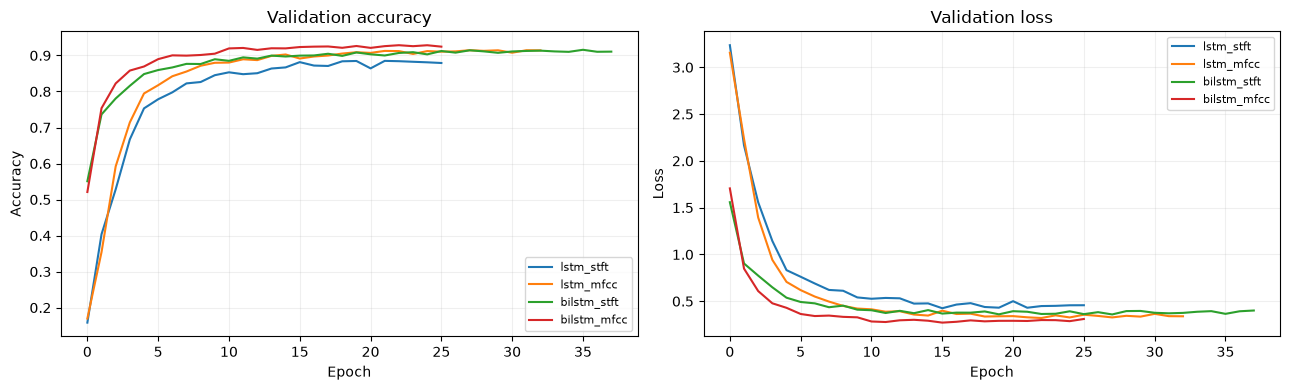

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, hist in histories.items():
    axes[0].plot(hist["val_accuracy"], label=name)
    axes[1].plot(hist["val_loss"], label=name)
axes[0].set(title="Validation accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].set(title="Validation loss", xlabel="Epoch", ylabel="Loss")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUT / "validation_curves.png", dpi=160)
plt.show()

## 5. Per-class metrics and confusion matrices

To examine performance beyond overall accuracy, I calculated precision, recall, and F1-score for each of the 35 classes. Confusion matrices are also generated to identify commands that are frequently misclassified.

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

metrics = []
for row in results:
    name = f"{row['model'].lower()}_{row['feature'].lower()}"
    model = tf.keras.models.load_model(PROJECT_ROOT / row["model_path"])
    y_true, y_pred = [], []
    for xb, yb in make_dataset("test", row["feature"]):
        scores = model.predict_on_batch(xb)
        y_true.extend(yb.numpy())
        y_pred.extend(np.argmax(scores, axis=1))
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    report = classification_report(y_true, y_pred, labels=np.arange(num_classes),
                                   target_names=labels, output_dict=True, zero_division=0)
    pd.DataFrame(report).T.to_csv(OUT / f"{name}_classification_report.csv")
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes), normalize="true")
    fig, ax = plt.subplots(figsize=(13, 12))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False,
                                                             xticks_rotation=90, values_format=".1f")
    ax.set_title(name)
    fig.tight_layout()
    fig.savefig(OUT / f"{name}_confusion_matrix.png", dpi=150)
    plt.close(fig)
    metrics.append(dict(model=name, accuracy=row["test_accuracy"],
                        macro_f1=float(f1_score(y_true, y_pred, average="macro", zero_division=0))))
    del model

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv(OUT / "classification_summary.csv", index=False)
display(metrics_df)

2026-10-08 20:46:52.475297: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,model,accuracy,macro_f1
0,lstm_stft,0.860245,0.849208
1,lstm_mfcc,0.903226,0.897835
2,bilstm_stft,0.894593,0.886430
3,bilstm_mfcc,0.917946,0.911976


## 6. Compare against CNN baseline

The recurrent models are compared against the CNN baseline using the same dataset partitions and label ordering.
The BiLSTM with MFCC features achieved the highest test accuracy, approximately 91.79%, followed by the LSTM with MFCC features at approximately 90.32%.
These results suggest that temporal modeling was beneficial for this dataset, particularly when using MFCC features.

In [7]:
cnn_baseline = pd.DataFrame([
    {"model": "CNN", "feature": "STFT", "test_accuracy": 0.822353},
    {"model": "CNN", "feature": "MFCC", "test_accuracy": 0.814539},
])
comparison = pd.concat([cnn_baseline, summary[["model", "feature", "test_accuracy"]]], ignore_index=True)
display(comparison.sort_values("test_accuracy", ascending=False))
comparison.to_csv(OUT / "cnn_rnn_comparison.csv", index=False)

,model,feature,test_accuracy
5,BiLSTM,MFCC,0.917946
3,LSTM,MFCC,0.903226
4,BiLSTM,STFT,0.894593
2,LSTM,STFT,0.860245
0,CNN,STFT,0.822353
1,CNN,MFCC,0.814539


## 7. Use a saved recurrent model in the microphone demo
The best-performing model, BiLSTM with MFCC features, was selected for the real-time microphone demonstration.
The application records audio, extracts MFCC features, and uses the trained model to predict one of the 35 commands.
Although the classifier performs well on the test dataset, real-world microphone recordings introduce additional challenges, including background noise and speech segmentation.